In [92]:
import tensorflow as tf

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
EPOCHS = 25
BATCH_SIZE = 16


CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### Linear NN for images

In [93]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the full training data (60,000 images)
(X_all, y_all), (_, _) = fashion_mnist.load_data()

# 2. Shuffle the data randomly
indices = np.arange(len(X_all))
np.random.seed(42)  # Ensures you get the same shuffle every time
np.random.shuffle(indices)

X_all = X_all[indices]
y_all = y_all[indices]

# 3. Split into 250 training and 20 testing images
X_train_small = X_all[:250]
y_train_small = y_all[:250]

X_test_small = X_all[250:270]
y_test_small = y_all[250:270]

print(f"Small Training Set Shape: {X_train_small.shape}")  # (250, 28, 28)
print(f"Small Testing Set Shape: {X_test_small.shape}")    # (20, 28, 28)


Small Training Set Shape: (250, 28, 28)
Small Testing Set Shape: (20, 28, 28)


In [94]:
# 3. Create the tf.data pipelines matching your exact style
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Quick verification check
print("Train batches:", len(list(train_dataset))) # 250 samples / 16 batch size = 15 batches
print("Eval batches:", len(list(eval_dataset)))   # 20 samples / 16 batch size = 2 batches

Train batches: 16
Eval batches: 2


In [95]:
for image_batch, label_batch in eval_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 28, 28)
Label batch shape: (16,)
Labels: [0 2 8 3 1 6 6 7 3 4 8 9 1 8 9 4]


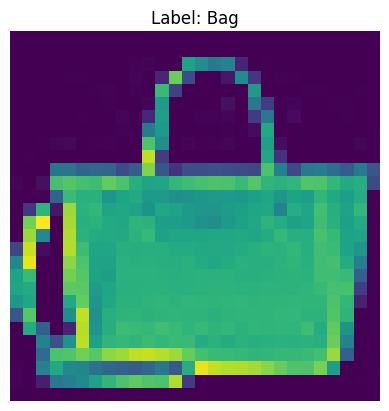

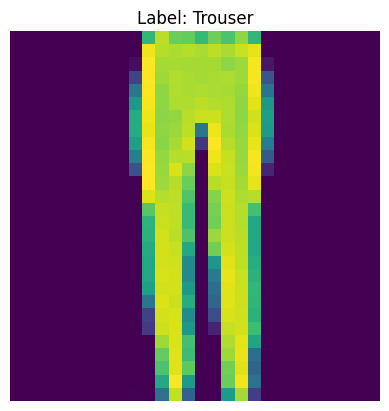

In [96]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

#### Linear Neural Network for image classification 

In [97]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

c:\Users\Debasish Das\.conda\envs\env1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [98]:

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2401 - loss: 106.8074 - val_accuracy: 0.4000 - val_loss: 58.4077
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5673 - loss: 31.0566 - val_accuracy: 0.5500 - val_loss: 40.8097
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 17.1564 - val_accuracy: 0.6500 - val_loss: 35.3922
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7862 - loss: 9.1842 - val_accuracy: 0.6500 - val_loss: 35.0016
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8023 - loss: 6.7853 - val_accuracy: 0.6000 - val_loss: 30.5552
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8562 - loss: 3.8553 - val_accuracy: 0.5500 - val_loss: 28.5707
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8052 - loss: 5.0393 - val_accuracy: 0.6000 - val_loss: 29.5798
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8514 - loss: 5.4213 - val_accuracy: 0.6500

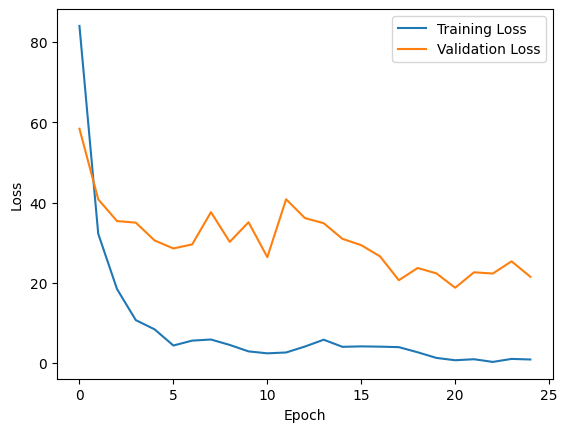

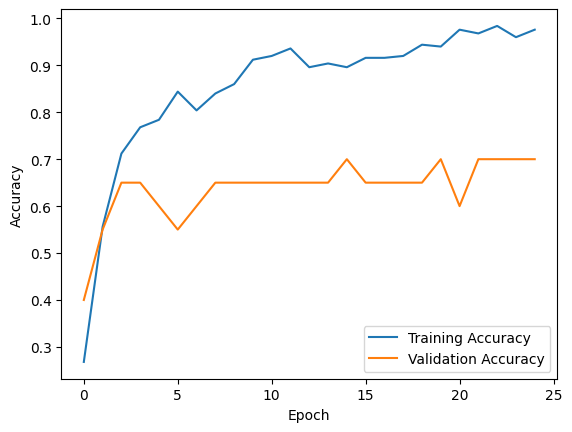

In [99]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


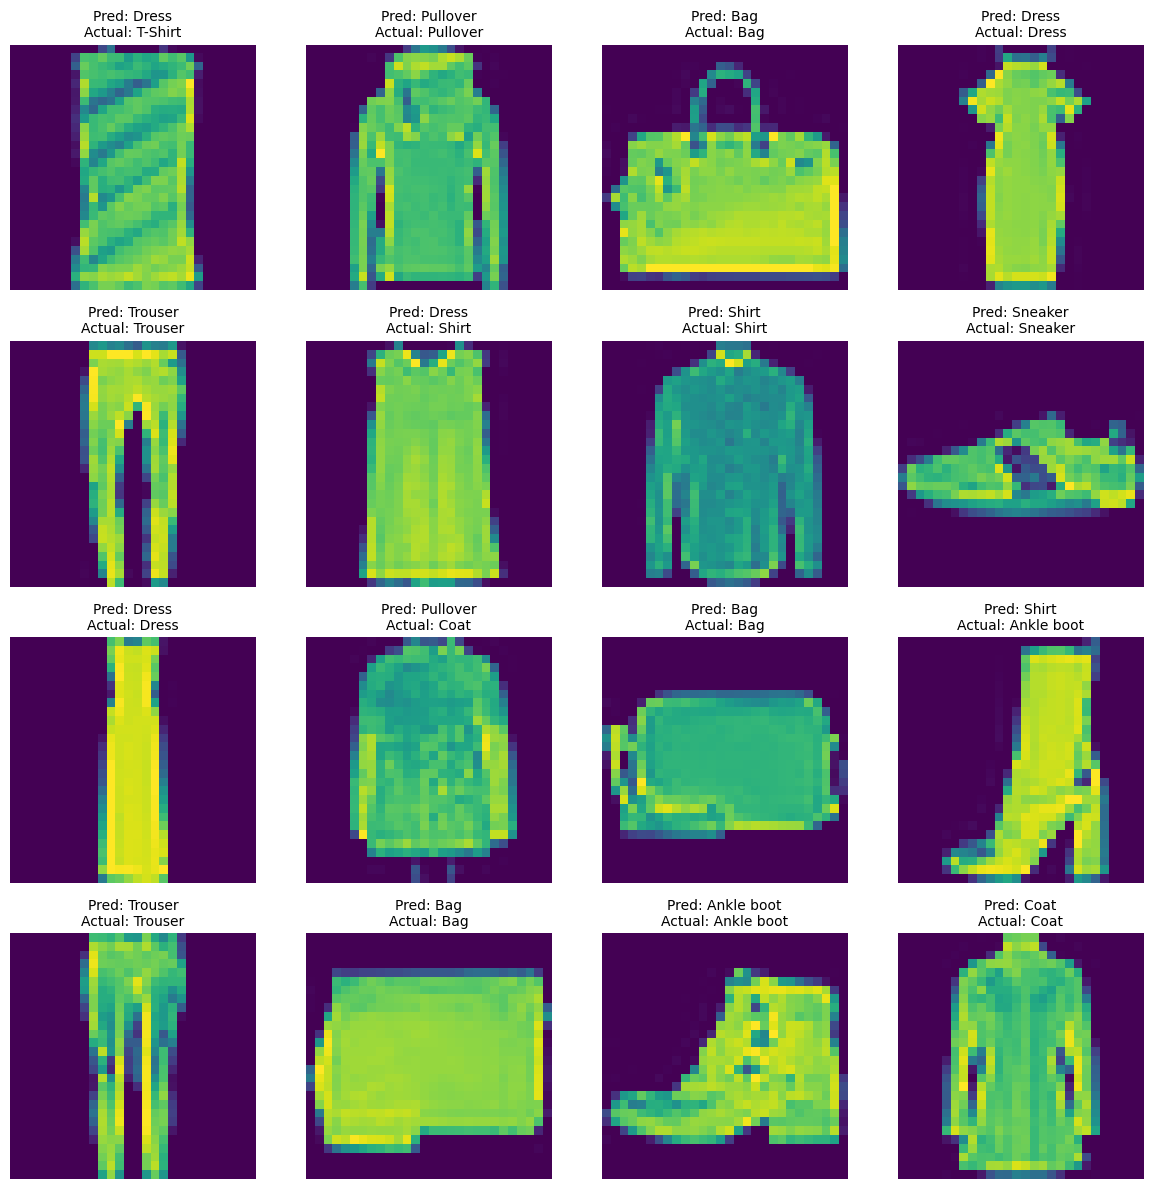

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

## Add Non-linearities to the Current Model

- Val accuracy: 0.70 -0.75
- val loss: 29.65
- Model is Overfitting and not generalizing well to the validation set.

In [106]:
# add Dropout layer to the model to reduce overfitting
updated_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

c:\Users\Debasish Das\.conda\envs\env1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Number of parameters in the model: 
- 1st layer: 28 X 28 X 1= 784
- 2nd layer: 128 X 784 + 128 = 100,480 
- 3rd layer: 10 X 128 + 10 = 1,290
- Total parameters: 102,754
- Total size of the model: 102,754 X 4 bytes = 411,016 bytes = 0.39 MB


In [107]:
updated_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [108]:
updated_history=updated_model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2301 - loss: 112.8714 - val_accuracy: 0.6000 - val_loss: 19.5668
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6362 - loss: 11.4365 - val_accuracy: 0.5500 - val_loss: 14.2632
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6551 - loss: 6.2789 - val_accuracy: 0.7500 - val_loss: 15.9110
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7876 - loss: 8.0469 - val_accuracy: 0.7000 - val_loss: 16.2033
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7623 - loss: 7.5750 - val_accuracy: 0.8000 - val_loss: 14.4171
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8076 - loss: 3.0413 - val_accuracy: 0.7500 - val_loss: 14.1528
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8709 - loss: 3.2671 - val_accuracy: 0.8000 - val_loss: 9.5652
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8497 - loss: 2.7770 - val_accuracy: 0.8000 -

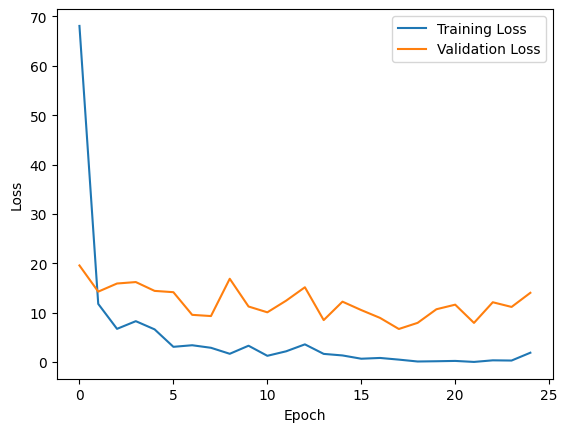

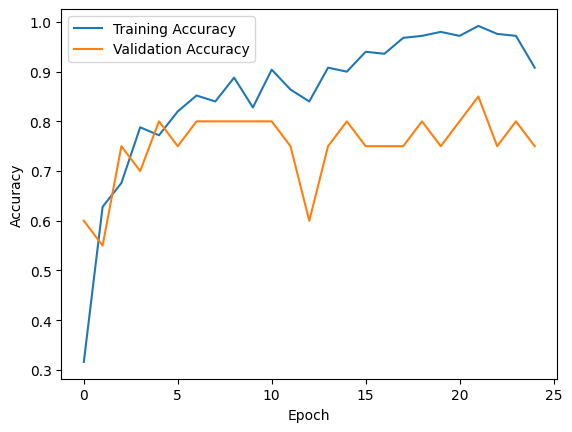

In [109]:
import matplotlib.pyplot as plt

plt.plot(updated_history.history["loss"], label="Training Loss")
plt.plot(updated_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(updated_history.history["accuracy"], label="Training Accuracy")
plt.plot(updated_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


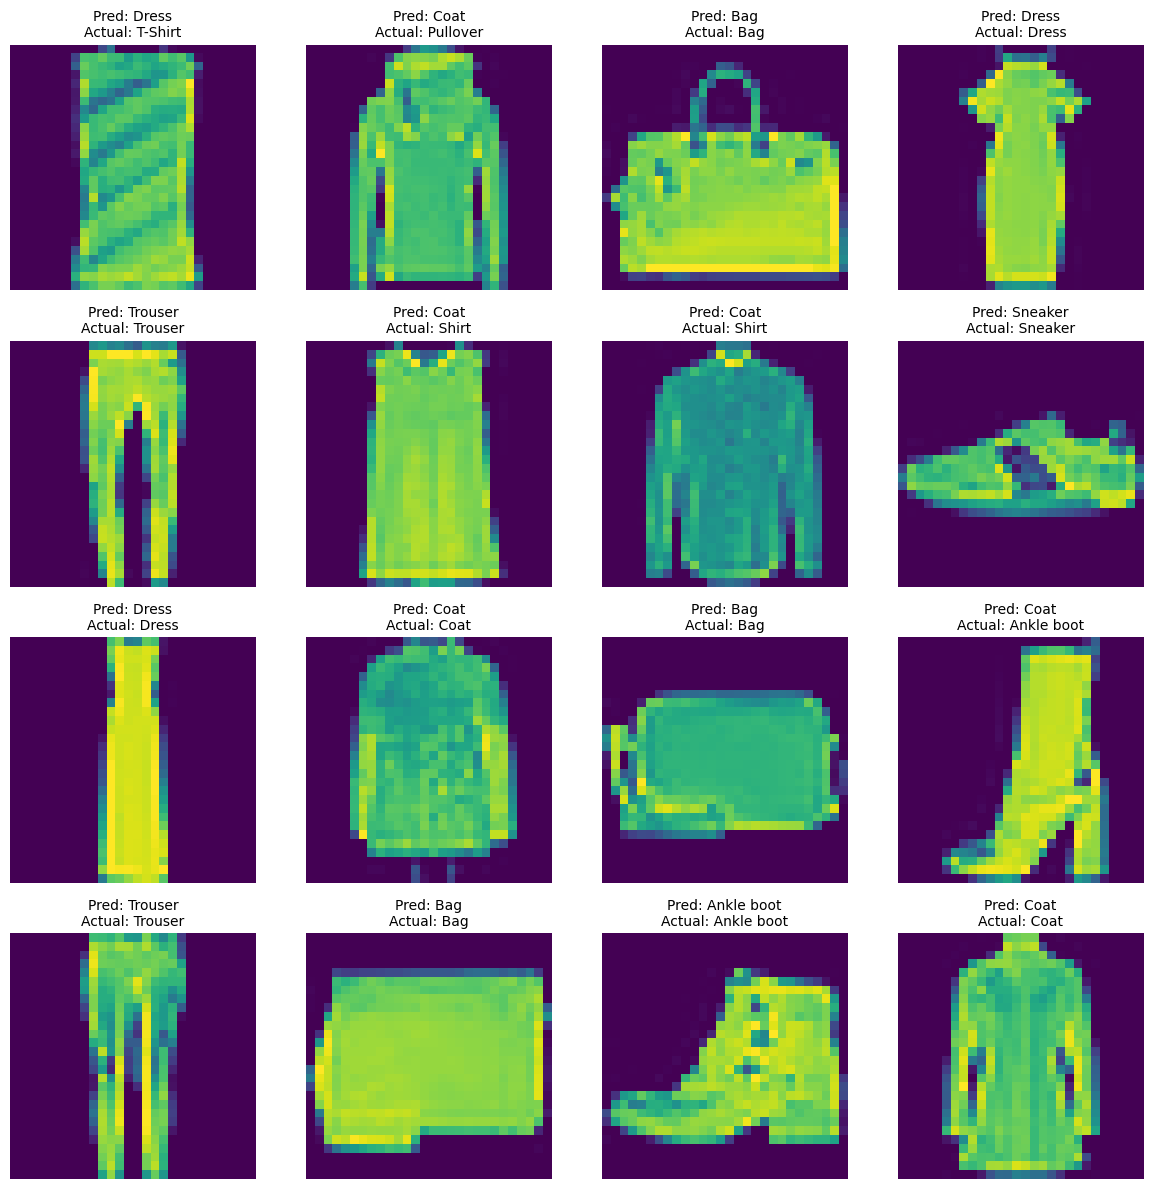

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = updated_model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

After adding Hidden layers 
- Loss is reduced but Accuracy not Increase
- To increase Accuracy, You have Tune Hyperparameter like BATCH_SIZE, Learning_Rate,Image Size

## Hyperparameter Tuning 